In [1]:
!!pip install -U -q langchain-google-genai

['\x1b[?25l   \x1b━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\x1b \x1b0.0/68.8 kB\x1b \x1b?\x1b eta \x1b-:--:--\x1b',
 '\x1b[2K   \x1b━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\x1b \x1b68.8/68.8 kB\x1b \x1b2.9 MB/s\x1b eta \x1b0:00:00\x1b',
 '\x1b[?25h']

In [2]:
from typing import TypedDict, List
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph,START,END

In [3]:
import os
from langchain.chat_models import init_chat_model
from google.colab import userdata

os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")

model = init_chat_model(
    model="gemini-2.5-flash",
    model_provider="google_genai"
)


In [4]:
class AgentState(TypedDict):
    messages: List[HumanMessage]




In [5]:
def process(state: AgentState) -> AgentState:
    response = model.invoke(state["messages"])
    print(f"\nAI: {response.content}")
    return state

In [6]:
graph = StateGraph(AgentState)
graph.add_node("process", process)
graph.add_edge(START, "process")
graph.add_edge("process", END)
agent = graph.compile()

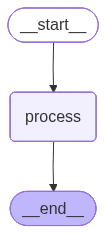

In [8]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

In [9]:
user_input = input("Enter: ")
while user_input != "exit":
    agent.invoke({"messages": [HumanMessage(content=user_input)]})
    user_input = input("Enter: ")

Enter: helllo

AI: Hello! How can I help you today?
Enter: i am  bored

AI: Oh no, boredom is the worst! Let's bust that feeling. To give you the best suggestions, tell me a little more, but in the meantime, here are a bunch of ideas across different categories:

**Get Creative:**

*   **Draw or Doodle:** Grab a pen and paper. No pressure, just let your hand move.
*   **Write:** Start a journal entry, a short story, a poem, or even just a list of things you're grateful for.
*   **Listen to or Make Music:** Discover a new artist, create a playlist for a specific mood, or try to learn a simple song on an instrument (even if it's just tapping rhythms).
*   **Cook or Bake:** Try a new recipe, experiment with ingredients you have, or just bake some cookies.
*   **DIY/Craft:** Look up a simple craft project online (origami, friendship bracelets, repurposing an old item).

**Learn Something New:**

*   **Watch a Documentary:** Pick a topic you've always been curious about.
*   **Listen to a P